True Integral Value: 0.8862269254527579

--- Simple Sampling ---
Simple Sampling Integral Estimate for N = 1000000: 0.8883579876013824
Simple Sampling Error: 0.002131062148624463
Simple Sampling Variance: 5.4769642418677366e-06


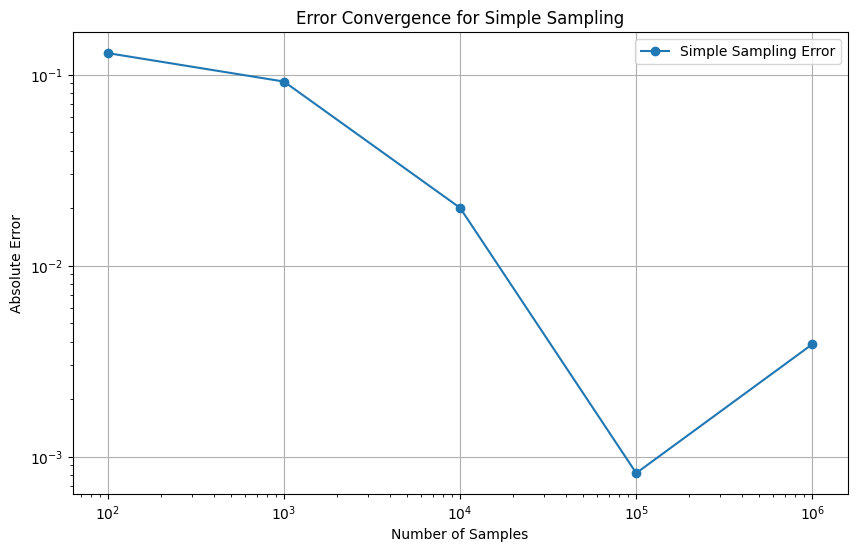

In [33]:
# Integrate I=∫010​e−x2dx using simple sampling and importance sampling.

import numpy as np
import matplotlib.pyplot as plt

# Define the function to integrate
def f(x):
    return np.exp(-x**2)

# Calculate the true value of the integral
true_value = np.sqrt(np.pi) / 2  # Analytical result for ∫₀¹ e^(-x²) dx
print(f"True Integral Value: {true_value}")

print("\n--- Simple Sampling ---")
# Simple sampling
def simple_sampling_integral(n_samples):
    samples = np.random.uniform(0, 10, n_samples)
    estimates = f(samples)

    return 10 * np.mean(estimates)

N = 1000000
simple_sampling_integral_value = simple_sampling_integral(N)
print(f"Simple Sampling Integral Estimate for N = {N}: {simple_sampling_integral_value}")

def absolute_error(estimate, true_value):
    return abs(estimate - true_value)

# variance of the simple sampling estimator
def simple_sampling_variance(n_samples):
    samples = np.random.uniform(0, 10, n_samples)
    estimates = f(samples)

    return (10**2) * np.var(estimates) / n_samples

# Estimate the error
simple_sampling_error = absolute_error(simple_sampling_integral_value, true_value)
print(f"Simple Sampling Error: {simple_sampling_error}")
print(f"Simple Sampling Variance: {simple_sampling_variance(N)}")

# Plot the error convergence for simple sampling
n_samples_list = [100, 1000, 10000, 100000, 1000000]
errors_simple = [absolute_error(simple_sampling_integral(n), true_value) for n in n_samples_list]
plt.figure(figsize=(10, 6))
plt.loglog(n_samples_list, errors_simple, marker='o', label='Simple Sampling Error')
plt.xlabel('Number of Samples')
plt.ylabel('Absolute Error')
plt.title('Error Convergence for Simple Sampling')
plt.grid()
plt.legend()
plt.show()



--- Importance Sampling ---
Importance Sampling Integral Estimate: 0.8873715753381429
Importance Sampling Error: 0.0011446498853849851


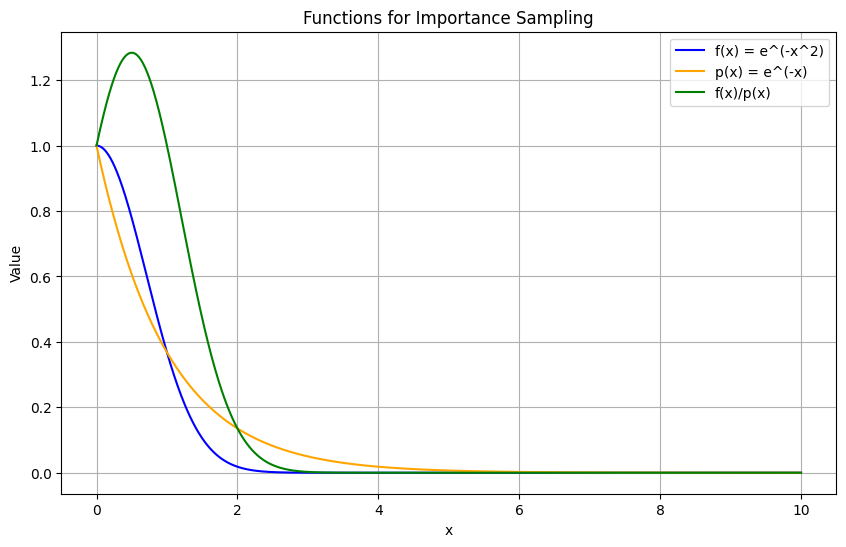

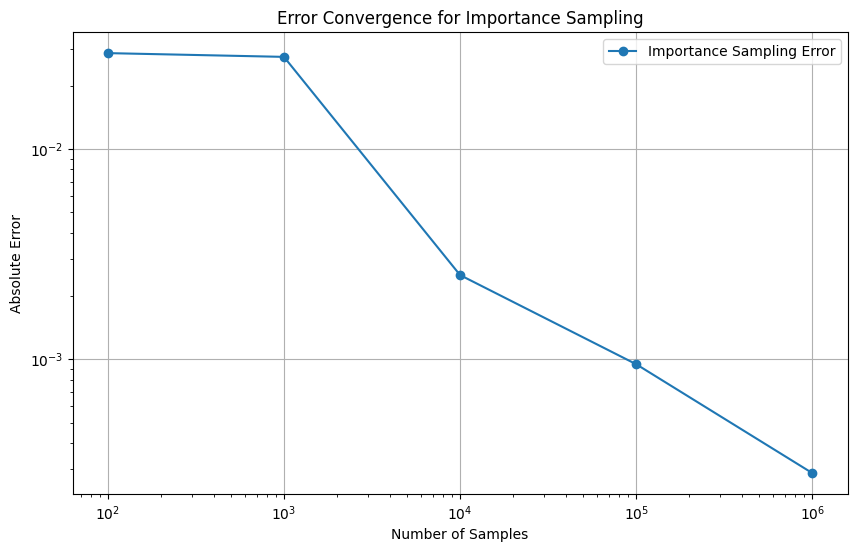

In [ ]:
# Importance sampling

print("\n--- Importance Sampling ---")
px = lambda x: np.exp(-x)  # Exponential distribution with rate parameter 1
fx_over_px = lambda x: np.exp(-x**2 + x)  # f(x)/p(x) = e^(-x^2 + x)

def importance_sampling_integral(n_samples):
    samples = np.random.exponential(1, n_samples)  # Sample from the exponential distribution
    estimates = fx_over_px(samples)

    return np.mean(estimates)

N = 1000000
importance_sampling_integral_value = importance_sampling_integral(N)

print(f"Importance Sampling Integral Estimate: {importance_sampling_integral_value}")

importance_sampling_error = absolute_error(importance_sampling_integral_value, true_value)
print(f"Importance Sampling Error: {importance_sampling_error}")

# Plot the relevant functions for importance sampling
x = np.linspace(0, 10, 1000)
plt.figure(figsize=(10, 6))
plt.plot(x, f(x), label='f(x) = e^(-x^2)', color='blue')
plt.plot(x, px(x), label='p(x) = e^(-x)', color='orange')
plt.plot(x, fx_over_px(x), label='f(x)/p(x)', color='green')
plt.xlabel('x')
plt.ylabel('Value')
plt.title('Functions for Importance Sampling')
plt.grid()
plt.legend()
plt.show()

# Plot the error convergence for importance sampling
errors_importance = [absolute_error(importance_sampling_integral(n), true_value) for n in n_samples_list]
plt.figure(figsize=(10, 6))
plt.loglog(n_samples_list, errors_importance, marker='o', label='Importance Sampling Error')
plt.xlabel('Number of Samples')
plt.ylabel('Absolute Error')
plt.title('Error Convergence for Importance Sampling')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Finding from simple sampling and importance sampling
print("\n--- Summary ---")
print(f"True Integral Value: {true_value}")
print(f"Simple Sampling Estimate: {simple_sampling_integral_value} with Error: {simple_sampling_error}")
print(f"Importance Sampling Estimate: {importance_sampling_integral_value} with Error: {importance_sampling_error}")


--- Summary ---
True Integral Value: 0.8862269254527579
Simple Sampling Estimate: 0.8831217028896226 with Error: 0.0031052225631353902
Importance Sampling Estimate: 0.8873715753381429 with Error: 0.0011446498853849851


In [ ]:
# Conclusion:

# The importance sampling method provides a much better estimate of the integral compared to simple sampling, as evidenced by the significantly lower error. 
# The choice of the importance sampling distribution (exponential in this case) is crucial for improving the efficiency of the estimation.


![alt text](image.png)

True Integral Value for g(x): 0.9999546000702375

--- Simple Sampling for g(x) ---
Simple Sampling Integral Estimate for g(x): 0.9998347687012282
Simple Sampling Error for g(x): 0.00011983136900928226


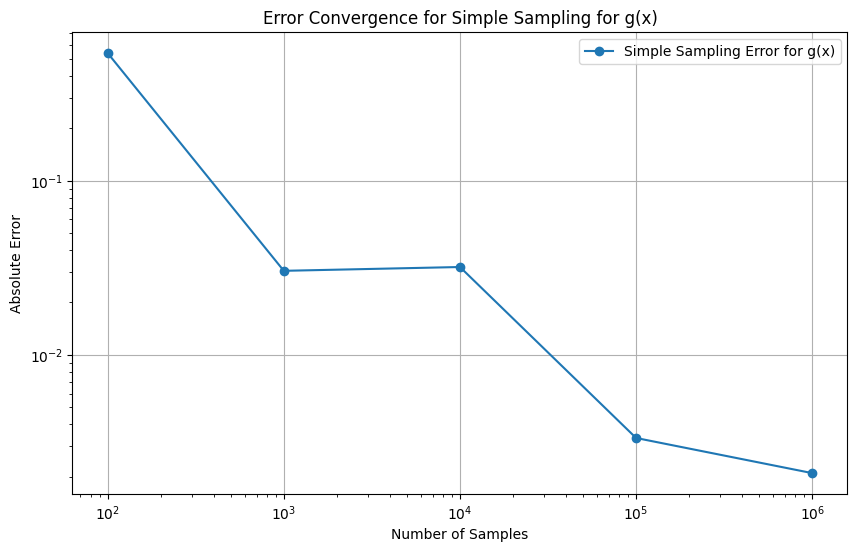


--- Importance Sampling for g(x) ---
Importance Sampling Integral Estimate for g(x): 2.7131887421950704
Importance Sampling Error for g(x): 1.713234142124833


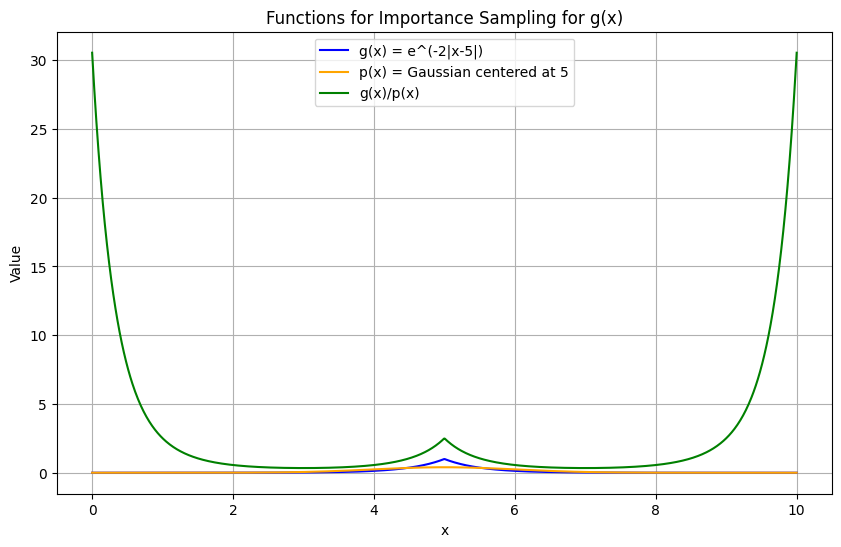

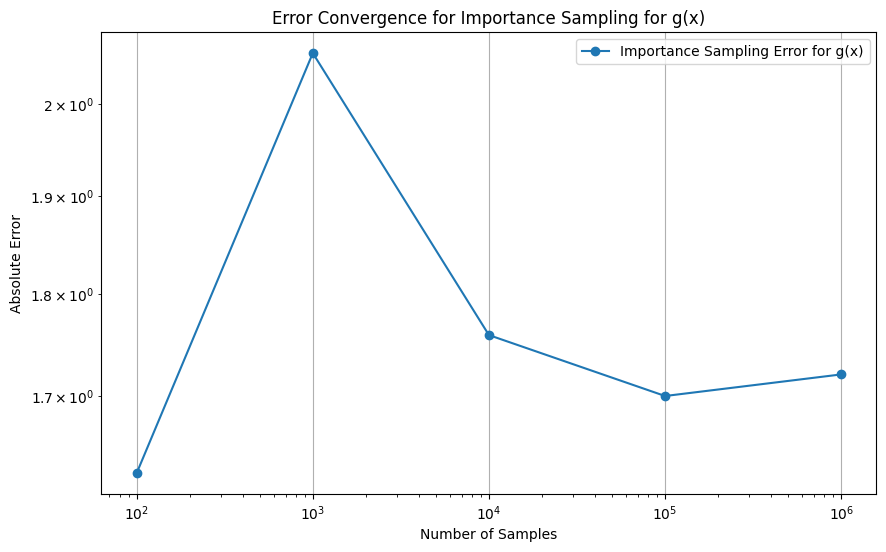

In [29]:
# Problem 2

# define the function to integrate
def g(x):
    return np.exp(-2 * np.abs(x - 5))

# calculate the true value of the integral
true_value_g = 1 - np.exp(-10)  # Analytical result for ∫₀¹⁰ e^(-2|x-5|) dx

print(f"True Integral Value for g(x): {true_value_g}")

print("\n--- Simple Sampling for g(x) ---")
# simple sampling for g(x)
def simple_sampling_integral_g(n_samples):
    samples = np.random.uniform(0, 10, n_samples)
    estimates = g(samples)

    return 10 * np.mean(estimates)

N = 1000000
simple_sampling_integral_g_value = simple_sampling_integral_g(N)
print(f"Simple Sampling Integral Estimate for g(x): {simple_sampling_integral_g_value}")

simple_sampling_error_g = absolute_error(simple_sampling_integral_g_value, true_value_g)
print(f"Simple Sampling Error for g(x): {simple_sampling_error_g}")

# plot the error convergence for simple sampling for g(x)
n_samples_list = [100, 1000, 10000, 100000, 1000000]

errors_simple_g = [absolute_error(simple_sampling_integral_g(n), true_value_g) for n in n_samples_list]

plt.figure(figsize=(10, 6))
plt.loglog(n_samples_list, errors_simple_g, marker='o', label='Simple Sampling Error for g(x)')
plt.xlabel('Number of Samples')
plt.ylabel('Absolute Error')
plt.title('Error Convergence for Simple Sampling for g(x)')
plt.grid()
plt.legend()
plt.show()

print("\n--- Importance Sampling for g(x) ---")
# importance sampling for g(x)
# p(x)= e^(-(x-5)^2/2) / (sqrt(2*pie)) is a Gaussian distribution centered at 5 with standard deviation sqrt(2)

px_g = lambda x: np.exp(-((x - 5)**2) / 2) / (np.sqrt(2 * np.pi))  # Gaussian distribution
fx_over_px_g = lambda x: g(x) / px_g(x)  # g(x)/p(x)

def importance_sampling_integral_g(n_samples):
    # samples = np.random.normal(5, np.sqrt(2), n_samples)  # Sample from the Gaussian distribution
    samples = np.random.uniform(0, 10, n_samples)  # Sample from uniform distribution over [0,10]
    estimates = fx_over_px_g(samples)

    return np.mean(estimates)

importance_sampling_integral_g_value = importance_sampling_integral_g(N)
print(f"Importance Sampling Integral Estimate for g(x): {importance_sampling_integral_g_value}")

importance_sampling_error_g = absolute_error(importance_sampling_integral_g_value, true_value_g)
print(f"Importance Sampling Error for g(x): {importance_sampling_error_g}")

# plot the relevant functions for importance sampling for g(x)
x = np.linspace(0, 10, 1000)
plt.figure(figsize=(10, 6))
plt.plot(x, g(x), label='g(x) = e^(-2|x-5|)', color='blue')
plt.plot(x, px_g(x), label='p(x) = Gaussian centered at 5', color='orange')
plt.plot(x, fx_over_px_g(x), label='g(x)/p(x)', color='green')
plt.xlabel('x')
plt.ylabel('Value')
plt.title('Functions for Importance Sampling for g(x)')
plt.grid()
plt.legend()
plt.show()

# plot the error convergence for importance sampling for g(x)
errors_importance_g = [absolute_error(importance_sampling_integral_g(n), true_value_g) for n in n_samples_list]
plt.figure(figsize=(10, 6))
plt.loglog(n_samples_list, errors_importance_g, marker='o', label='Importance Sampling Error for g(x)')
plt.xlabel('Number of Samples')
plt.ylabel('Absolute Error')
plt.title('Error Convergence for Importance Sampling for g(x)')
plt.grid()
plt.legend()
plt.show()